In [1]:
# First TSS extraction from .gtf file
## 1. For all 2. For DEGs
###

In [2]:
import pandas as pd
import re

# Load GTF
gtf = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/gencode.v48.chr_patch_hapl_scaff.annotation.gtf",
    sep="\t", comment="#", header=None,
    names=["chr","source","feature","start","end","score","strand","frame","attribute"]
)

# Keep only "gene" rows
genes = gtf[gtf["feature"]=="gene"].copy()

# Extract gene_id, strip version
genes["gene_id"] = genes["attribute"].str.extract(r'gene_id "([^"]+)"')
genes["gene_id"] = genes["gene_id"].str.replace(r"\.\d+$","",regex=True)

# Extract gene_name and type
genes["gene_name"] = genes["attribute"].str.extract(r'gene_name "([^"]+)"')
genes["gene_type"] = genes["attribute"].str.extract(r'gene_type "([^"]+)"')
genes

,chr,source,feature,start,end,score,strand,frame,attribute,gene_id,gene_name,gene_type
0,chr1,HAVANA,gene,11121,24894,.,+,.,"gene_id ""ENSG00000290825.2""; gene_type ""lncRNA...",ENSG00000290825,DDX11L16,lncRNA
124,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6""; gene_type ""transc...",ENSG00000223972,DDX11L1,transcribed_unprocessed_pseudogene
132,chr1,HAVANA,gene,14356,30744,.,-,.,"gene_id ""ENSG00000310526.1""; gene_type ""lncRNA...",ENSG00000310526,WASH7P,lncRNA
2403,chr1,HAVANA,gene,14696,24886,.,-,.,"gene_id ""ENSG00000227232.6""; gene_type ""transc...",ENSG00000227232,WASH7P,transcribed_unprocessed_pseudogene
2415,chr1,ENSEMBL,gene,17369,17436,.,-,.,"gene_id ""ENSG00000278267.1""; gene_type ""miRNA""...",ENSG00000278267,MIR6859-1,miRNA
...,...,...,...,...,...,...,...,...,...,...,...,...
4419770,KI270751.1,HAVANA,gene,2579,73732,.,-,.,"gene_id ""ENSG00000303867.1""; gene_type ""lncRNA...",ENSG00000303867,ENSG00000303867,lncRNA
4420073,KI270751.1,HAVANA,gene,34096,71851,.,+,.,"gene_id ""ENSG00000303902.1""; gene_type ""lncRNA...",ENSG00000303902,ENSG00000303902,lncRNA
4420142,KI270751.1,HAVANA,gene,133801,139253,.,-,.,"gene_id ""ENSG00000306528.1""; gene_type ""lncRNA...",ENSG00000306528,ENSG00000306528,lncRNA
4420150,KI270753.1,HAVANA,gene,43135,44491,.,+,.,"gene_id ""ENSG00000297844.1""; gene_type ""lncRNA...",ENSG00000297844,ENSG00000297844,lncRNA


In [3]:
#1.
# 
#  Compute TSS (1-bp window)

tss0 = (genes["start"]-1).where(genes["strand"]=="+", genes["end"]-1)
tss1 = tss0 + 1

tss_bed = pd.DataFrame({
    "chrom": genes["chr"],
    "start": tss0.astype(int),
    "end":   tss1.astype(int),
    "name":  genes["gene_id"],
    "score": 0,
    "strand": genes["strand"]
}).sort_values(["chrom","start","end"])

tss_bed

# Save to file
tss_bed.to_csv("all_genes_TSS_gtfgencode.bed", sep="\t", header=False, index=False)

In [4]:
#2. 
# 
# DEGs subset

# Load DEGs already filtered for padj & LFC
up_ids   = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt", sep="\t", header=None)[0].str.replace(r"\.\d+$","",regex=True)
down_ids = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt", sep="\t", header=None)[0].str.replace(r"\.\d+$","",regex=True)

down_ids

0          ensembl_id
1     ENSG00000026036
2     ENSG00000101246
3     ENSG00000103269
4     ENSG00000105173
           ...       
78    ENSG00000290076
79    ENSG00000290548
80    ENSG00000291100
81    ENSG00000291117
82    ENSG00000307581
Name: 0, Length: 83, dtype: object

In [5]:
# Filter
up_tss   = tss_bed[tss_bed["name"].isin(up_ids)]
down_tss = tss_bed[tss_bed["name"].isin(down_ids)]

down_tss

,chrom,start,end,name,score,strand
8817,chr1,960583,960584,ENSG00000187961,0,+
11201,chr1,1309608,1309609,ENSG00000131584,0,-
13718,chr1,1615453,1615454,ENSG00000197530,0,+
25237,chr1,6205474,6205475,ENSG00000158286,0,+
25954,chr1,6466174,6466175,ENSG00000215788,0,-
...,...,...,...,...,...,...
1892431,chr8,144466042,144466043,ENSG00000167702,0,+
1892608,chr8,144477968,144477969,ENSG00000160972,0,+
1926648,chr9,35690055,35690056,ENSG00000198467,0,-
1966125,chr9,83921464,83921465,ENSG00000165115,0,-


In [6]:
# Save
up_tss.to_csv("up_TSS_DEGs_gtfgencode.bed", sep="\t", header=False, index=False)
down_tss.to_csv("down_TSS_DEGs_gtfgencode.bed", sep="\t", header=False, index=False)

---

In [7]:
# load DESeq2 results
deseq = pd.read_csv("deseq_results_full_cpionly_3sep.tsv", sep="\t")
deseq["gene_id"] = deseq["gene_id"].astype(str).str.replace(r"\.\d+$","",regex=True)

# load gene annotation (from GTF you parsed earlier)
# gtf_genes already had chr, start, end, strand, gene_id, gene_name, gene_type
ann = genes.merge(deseq, on="gene_id", how="left")
ann


,chr,source,feature,start,end,score,strand,frame,attribute,gene_id,gene_name,gene_type,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,chr1,HAVANA,gene,11121,24894,.,+,.,"gene_id ""ENSG00000290825.2""; gene_type ""lncRNA...",ENSG00000290825,DDX11L16,lncRNA,0.280936,-2.422587,4.904300,-0.493972,0.621326,NaN
1,chr1,HAVANA,gene,12010,13670,.,+,.,"gene_id ""ENSG00000223972.6""; gene_type ""transc...",ENSG00000223972,DDX11L1,transcribed_unprocessed_pseudogene,0.000000,NaN,NaN,NaN,NaN,NaN
2,chr1,HAVANA,gene,14356,30744,.,-,.,"gene_id ""ENSG00000310526.1""; gene_type ""lncRNA...",ENSG00000310526,WASH7P,lncRNA,227.447545,-0.189165,0.321656,-0.588097,0.556467,0.806729
3,chr1,HAVANA,gene,14696,24886,.,-,.,"gene_id ""ENSG00000227232.6""; gene_type ""transc...",ENSG00000227232,WASH7P,transcribed_unprocessed_pseudogene,0.000000,NaN,NaN,NaN,NaN,NaN
4,chr1,ENSEMBL,gene,17369,17436,.,-,.,"gene_id ""ENSG00000278267.1""; gene_type ""miRNA""...",ENSG00000278267,MIR6859-1,miRNA,0.000000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86359,KI270751.1,HAVANA,gene,2579,73732,.,-,.,"gene_id ""ENSG00000303867.1""; gene_type ""lncRNA...",ENSG00000303867,ENSG00000303867,lncRNA,0.000000,NaN,NaN,NaN,NaN,NaN
86360,KI270751.1,HAVANA,gene,34096,71851,.,+,.,"gene_id ""ENSG00000303902.1""; gene_type ""lncRNA...",ENSG00000303902,ENSG00000303902,lncRNA,0.000000,NaN,NaN,NaN,NaN,NaN
86361,KI270751.1,HAVANA,gene,133801,139253,.,-,.,"gene_id ""ENSG00000306528.1""; gene_type ""lncRNA...",ENSG00000306528,ENSG00000306528,lncRNA,0.000000,NaN,NaN,NaN,NaN,NaN
86362,KI270753.1,HAVANA,gene,43135,44491,.,+,.,"gene_id ""ENSG00000297844.1""; gene_type ""lncRNA...",ENSG00000297844,ENSG00000297844,lncRNA,0.000000,NaN,NaN,NaN,NaN,NaN


In [8]:
padj_thr, lfc_thr = 0.1, 0.6
ann["regulation"] = "nonDE"
ann.loc[(ann["padj"]<padj_thr) & (ann["log2FoldChange"]>= lfc_thr), "regulation"] = "up"
ann.loc[(ann["padj"]<padj_thr) & (ann["log2FoldChange"]<=-lfc_thr), "regulation"] = "down"

up   = ann[ann["regulation"]=="up"]
down = ann[ann["regulation"]=="down"]

print("UP:", len(up), "DOWN:", len(down))

UP: 222 DOWN: 82


In [9]:
def export_bg(subset_label, out_bed, N_bins=5):
    sub = ann[ann["regulation"]==subset_label].copy()
    bg  = ann[ann["regulation"]=="nonDE"].copy()
    bg["bin"]  = pd.qcut(bg["baseMean"].rank(method="first"), N_bins, duplicates="drop")
    sub["bin"] = pd.qcut(sub["baseMean"].rank(method="first"), N_bins, duplicates="drop")

    rows=[]
    for (chrom, b), part in sub.groupby(["chr","bin"]):
        pool = bg[(bg["chr"]==chrom)&(bg["bin"]==b)]
        k = len(part)
        if len(pool) < k: pool = bg[bg["chr"]==chrom]
        rows.append(pool.sample(min(k,len(pool)), random_state=42))
    bg_match = pd.concat(rows)

    tss0 = (bg_match["start"]-1).where(bg_match["strand"]=="+", bg_match["end"]-1).astype(int)
    bed = pd.DataFrame({
        "chrom": bg_match["chr"], "start": tss0, "end": tss0+1,
        "name": bg_match["gene_id"], "score": 0, "strand": bg_match["strand"]
    }).sort_values(["chrom","start","end"])
    bed.to_csv(out_bed, sep="\t", header=False, index=False)

export_bg("up",   "bg_up_TSS.bed")
export_bg("down", "bg_down_TSS.bed")


/tmp/ipykernel_2475955/952554816.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (chrom, b), part in sub.groupby(["chr","bin"]):
/tmp/ipykernel_2475955/952554816.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (chrom, b), part in sub.groupby(["chr","bin"]):


# main
loopanchor_deg_stat.sh


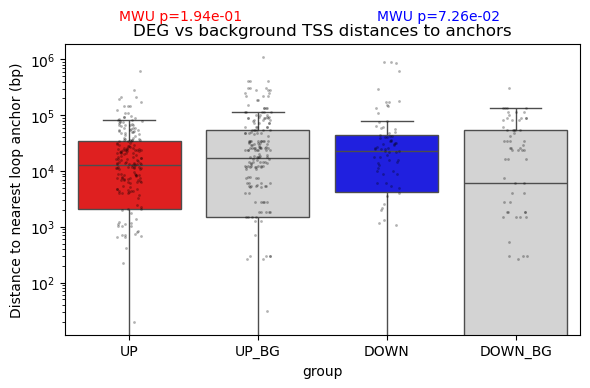

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load distances again
up   = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/up_to_anchor.closest.tsv", sep="\t", header=None)
bgup = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/bg_up_to_anchor.closest.tsv", sep="\t", header=None)
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/down_to_anchor.closest.tsv", sep="\t", header=None)
bgdown = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/bg_down_to_anchor.closest.tsv", sep="\t", header=None)

df = pd.DataFrame({
    "distance": pd.concat([up.iloc[:,-1], bgup.iloc[:,-1],
                           down.iloc[:,-1], bgdown.iloc[:,-1]]).astype(int),
    "group": (["UP"]*len(up) + ["UP_BG"]*len(bgup) +
              ["DOWN"]*len(down) + ["DOWN_BG"]*len(bgdown))
})

# Known Mann–Whitney p-values (from your script)
p_up = 1.94e-01
p_down = 7.26e-02

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="group", y="distance", hue="group",
            palette={"UP":"red","UP_BG":"lightgray","DOWN":"blue","DOWN_BG":"lightgray"},
            showfliers=False, legend=False)
sns.stripplot(data=df, x="group", y="distance", color="black", alpha=0.3, size=2)

plt.yscale("log")
plt.ylabel("Distance to nearest loop anchor (bp)")
plt.title("DEG vs background TSS distances to anchors")

# Add p-value annotations
plt.text(0.4, 5e6, f"MWU p={p_up:.2e}", ha="center", color="red")
plt.text(2.4, 5e6, f"MWU p={p_down:.2e}", ha="center", color="blue")

plt.tight_layout()
plt.savefig("deg_anchor_distance_boxplot_annotated.png", dpi=200)
plt.show()

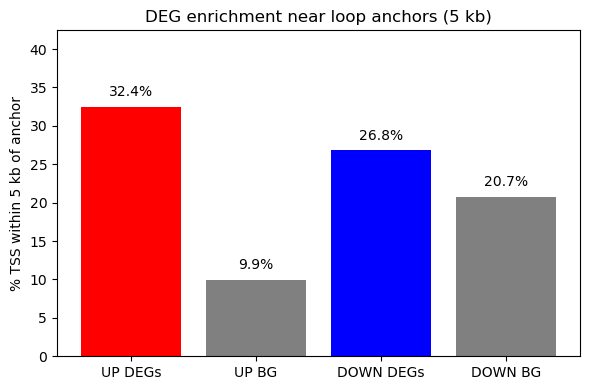

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Your 5 kb counts from Fisher’s test results
# [near, not-near]
up_table   = [72, 150]
bg_up_table = [22, 200]
down_table   = [22, 60]
bg_down_table = [17, 65]

# Percentages
up_pct   = 100 * up_table[0]   / sum(up_table)
bg_up_pct = 100 * bg_up_table[0] / sum(bg_up_table)
down_pct   = 100 * down_table[0]   / sum(down_table)
bg_down_pct = 100 * bg_down_table[0] / sum(bg_down_table)

labels = ["UP DEGs","UP BG","DOWN DEGs","DOWN BG"]
values = [up_pct, bg_up_pct, down_pct, bg_down_pct]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, values, color=["red","gray","blue","gray"])
plt.ylabel("% TSS within 5 kb of anchor")
plt.title("DEG enrichment near loop anchors (5 kb)")
plt.ylim(0, max(values)+10)
for bar,v in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, v+1, f"{v:.1f}%", ha='center', va='bottom')
plt.tight_layout()
plt.savefig("deg_anchor_proximity_barplot.png", dpi=200)
plt.show()

/tmp/ipykernel_2475955/315383696.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)


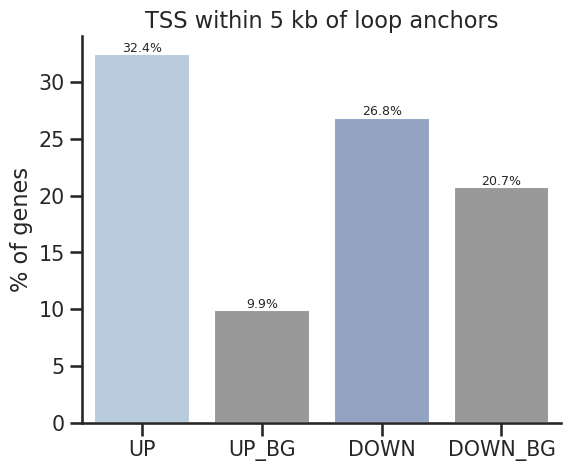

In [13]:
# === Prepare data ===
# counts: [near, not-near]
counts = {
    "UP":      [72, 150],
    "UP_BG":   [22, 200],
    "DOWN":    [22, 60],
    "DOWN_BG": [17, 65],
}

df = []
for label,(near,notnear) in counts.items():
    total = near+notnear
    pct   = 100*near/total
    df.append({"Group": label, "Near_5kb": near, "Total": total, "%Near": pct})
df = pd.DataFrame(df)

# === Plot ===
custom_palette = {"UP":"#b3cde3", "UP_BG":"#999999",
                  "DOWN":"#8da0cb", "DOWN_BG":"#999999"}

sns.set_theme(style="ticks", rc={"axes.spines.top": False, "axes.spines.right": False})
sns.set_context("talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(data=df, x="Group", y="%Near", palette=custom_palette, ax=ax)

ax.set_title("TSS within 5 kb of loop anchors")
ax.set_xlabel("")
ax.set_ylabel("% of genes")

# Annotate values on bars
for p in ax.patches:
    value = p.get_height()
    ax.annotate(f"{value:.1f}%",
                (p.get_x() + p.get_width() / 2., value),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("deg_anchor_proximity_barplot.png", dpi=200)
plt.show()
